In [11]:
from fista.lr import LogisticRegression
from sklearn.linear_model import LogisticRegression as LogisticRegressionSKL
from sklearn.model_selection import train_test_split
from experiments.utils import (
    evaluate_model,
    generate_data,
    generate_data_probit,
    plot_beta_comparison,
    plot_convergence,
)
import numpy as np

In [12]:
coefs = np.zeros(17)
coefs[0:4] = np.random.normal(1, 1, size=4)
coefs[4:8] = np.random.normal(-2, 1, size=4)
coefs[8:12] = 3
coefs[12:17] = np.random.normal(7, 1, size=5)

## Beta Comparison

### Logistic model
Data generated from a true logistic model - the assumptions are satisfied. We compare metrics and coefficient estimates for FISTA, liblinear, and saga.

In [13]:
X, y, beta_true = generate_data(coefs, n=5000, k=20, alpha=-1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=7
)

lr1 = LogisticRegression(lmbd=2, max_iter=1000, tol=1e-5)
lr2 = LogisticRegressionSKL(
    l1_ratio=1, C=1, max_iter=1000, solver="liblinear", tol=1e-5
)
lr3 = LogisticRegressionSKL(l1_ratio=1, C=1, max_iter=1000, solver="saga", tol=1e-5)
lr1.fit(X_train, y_train)
lr2.fit(X_train, y_train)
lr3.fit(X_train, y_train)

models = {"fista": lr1, "liblinear": lr2, "saga": lr3}

results = {}

for name, model in models.items():
    results[name] = evaluate_model(model, X_test, y_test)

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")


fista:
  accuracy: 0.9640
  recall: 0.9648
  precision: 0.9594
  f1: 0.9621
  balanced_accuracy: 0.9640
  roc_auc: 0.9962
  average_precision: 0.9958

liblinear:
  accuracy: 0.9640
  recall: 0.9648
  precision: 0.9594
  f1: 0.9621
  balanced_accuracy: 0.9640
  roc_auc: 0.9961
  average_precision: 0.9958

saga:
  accuracy: 0.9640
  recall: 0.9648
  precision: 0.9594
  f1: 0.9621
  balanced_accuracy: 0.9640
  roc_auc: 0.9961
  average_precision: 0.9958


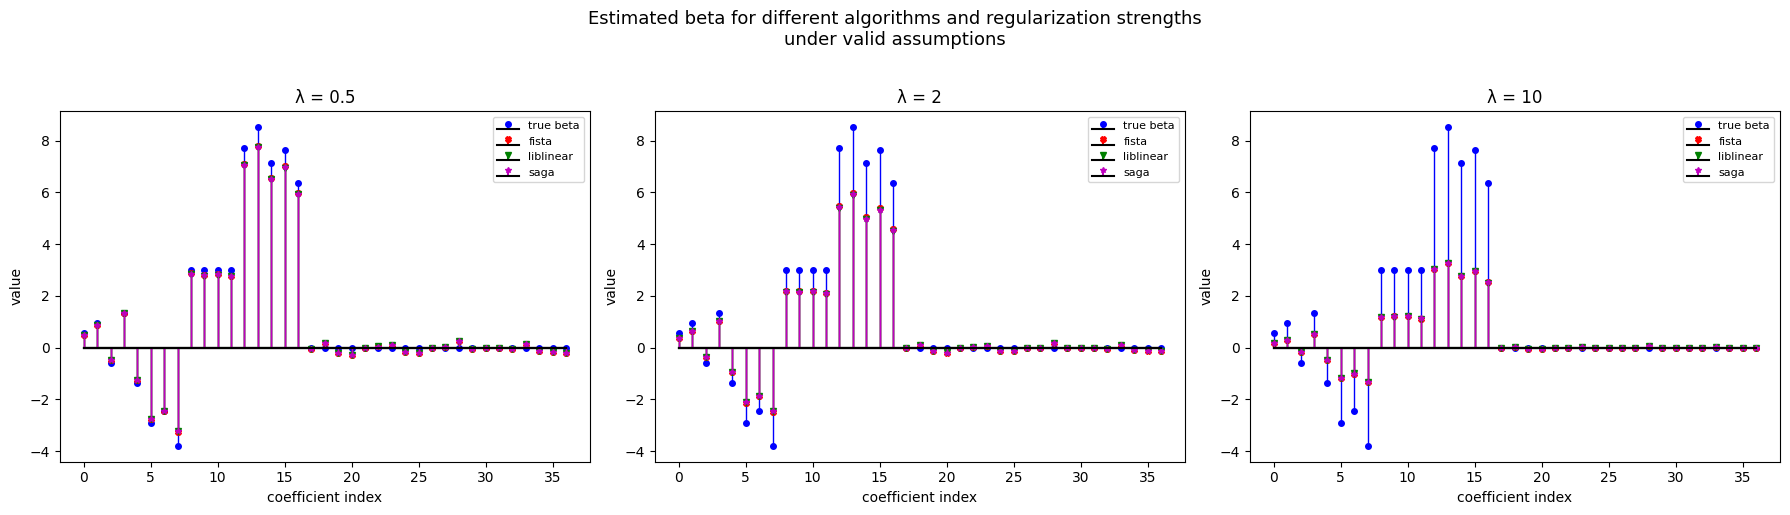

In [14]:
lambdas = [0.5, 2, 10]
plot_beta_comparison(
    X_train, y_train, beta_true, lambdas,
    title="Estimated beta for different algorithms and regularization strengths\nunder valid assumptions",
)

### Non-logistic model
Data generated from a probit model with correlated features, pairwise interactions, and quadratic terms - logistic model assumptions are violated.

In [15]:
X, y, beta_true = generate_data_probit(coefs, n=5000, k=20, alpha=-1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=7
)

lr1 = LogisticRegression(lmbd=2, max_iter=1000, tol=1e-5)
lr2 = LogisticRegressionSKL(
    l1_ratio=1, C=0.5, max_iter=1000, solver="liblinear", tol=1e-5
)
lr3 = LogisticRegressionSKL(l1_ratio=1, C=0.5, max_iter=1000, solver="saga", tol=1e-5)
lr1.fit(X_train, y_train)
lr2.fit(X_train, y_train)
lr3.fit(X_train, y_train)

models = {"fista": lr1, "liblinear": lr2, "saga": lr3}

results = {}

for name, model in models.items():
    results[name] = evaluate_model(model, X_test, y_test)

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")


fista:
  accuracy: 0.8073
  recall: 0.8791
  precision: 0.8397
  f1: 0.8590
  balanced_accuracy: 0.7712
  roc_auc: 0.8972
  average_precision: 0.9558

liblinear:
  accuracy: 0.8073
  recall: 0.8791
  precision: 0.8397
  f1: 0.8590
  balanced_accuracy: 0.7712
  roc_auc: 0.8972
  average_precision: 0.9558

saga:
  accuracy: 0.8073
  recall: 0.8791
  precision: 0.8397
  f1: 0.8590
  balanced_accuracy: 0.7712
  roc_auc: 0.8972
  average_precision: 0.9558


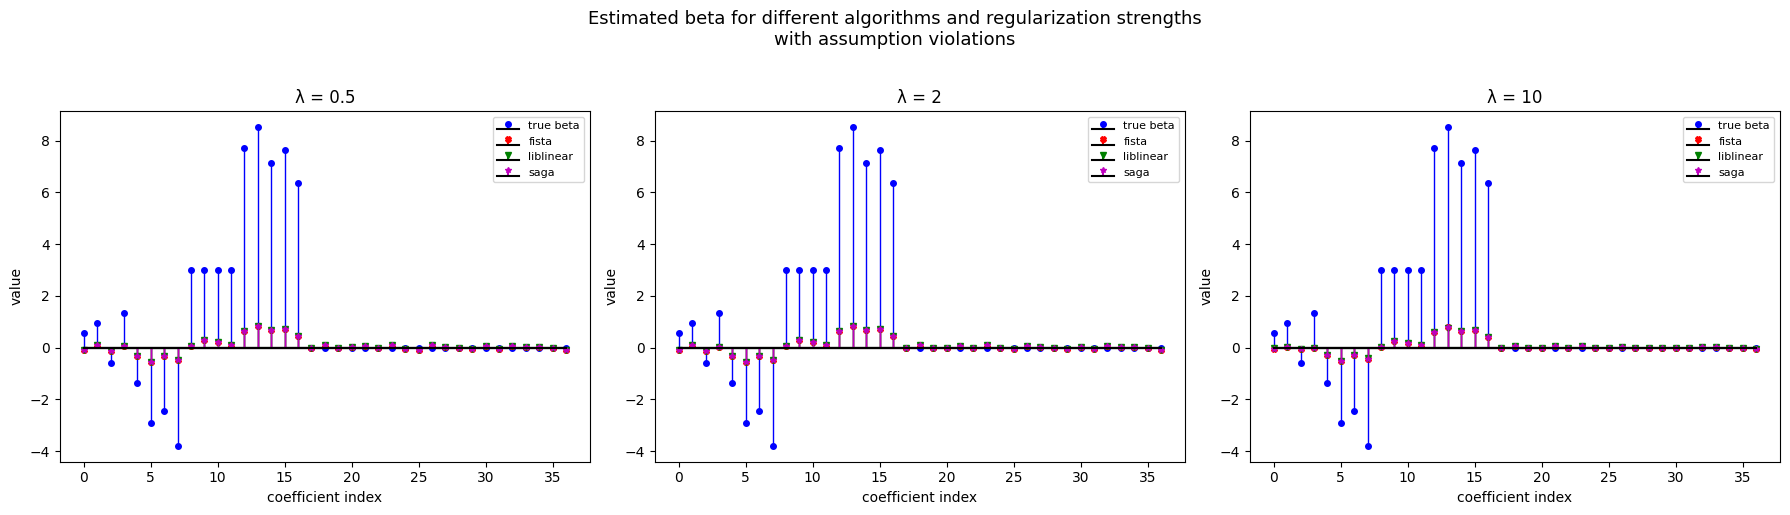

In [16]:
lambdas = [0.5, 2, 10]
plot_beta_comparison(
    X_train, y_train, beta_true, lambdas,
    title="Estimated beta for different algorithms and regularization strengths\nwith assumption violations",
)

## Convergence

### Logistic model
100 runs of FISTA on logistic data, tracking objective and beta error convergence with 95% CIs.

In [17]:
results = []
for i in range(100):
    X, y, beta_true = generate_data(coefs, n=5000, k=20, alpha=-1)
    lr = LogisticRegression(lmbd=2, max_iter=1000, tol=0)
    lr.fit(X, y, beta_true)
    results.append(lr.convergence_history)

objective = np.array([run["objective"] for run in results])
beta_error = np.array([run["beta_error"] for run in results])

/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 2, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 2, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 2, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 2, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 2, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 2, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/am

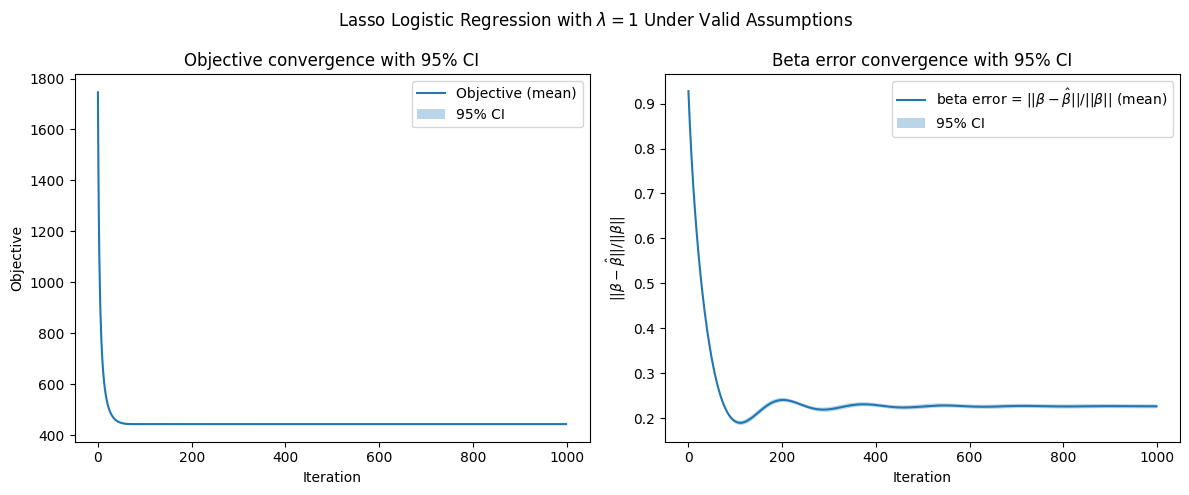

In [18]:
plot_convergence(
    objective, beta_error,
    title=r"Lasso Logistic Regression with $\lambda=1$ Under Valid Assumptions",
)

### Non-logistic model
100 runs of FISTA on data with assumption violations, tracking objective and beta error convergence with 95% CIs.

In [19]:
results = []
for i in range(100):
    X, y, beta_true = generate_data_probit(coefs, n=5000, k=20, alpha=-1)
    lr = LogisticRegression(lmbd=2, max_iter=1000, tol=0)
    lr.fit(X, y, beta_true)
    results.append(lr.convergence_history)

objective = np.array([run["objective"] for run in results])
beta_error = np.array([run["beta_error"] for run in results])

/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 2, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 2, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 2, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 2, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 2, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 2, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/am

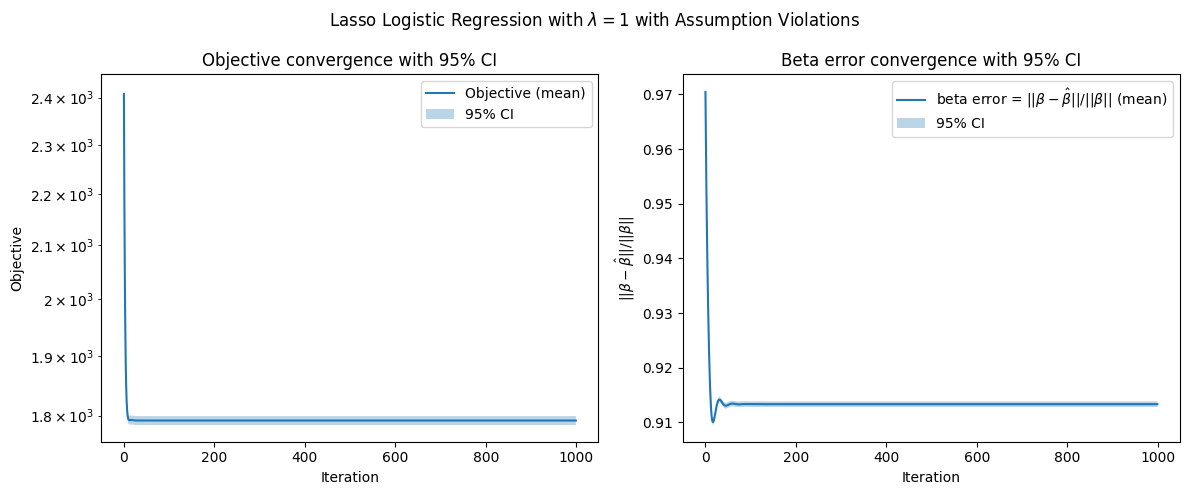

In [20]:
plot_convergence(
    objective, beta_error,
    title=r"Lasso Logistic Regression with $\lambda=1$ with Assumption Violations",
    log_scale_obj=True,
)